In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 165.5 kB/s eta 0:00:00


Representasi data yang tepat sangat menentukan keberhasilan algoritma machine learning, mulai dari penskalaan manual hingga penggunaan pembelajaran tidak terstruktur untuk mengekstraksi fitur. Oleh karena itu, sebagian besar aplikasi memerlukan rangkaian proses yang menggabungkan berbagai tahap pemrosesan data dengan model prediksi. Penggunaan kelas Pipeline sangat penting untuk menyederhanakan alur kerja ini, karena memungkinkan kita mengintegrasikan transformasi data dan model ke dalam satu kesatuan. Dengan menggabungkan Pipeline dan GridSearchCV, kita dapat mengoptimalkan parameter untuk seluruh tahapan pemrosesan secara sekaligus, yang terbukti mampu meningkatkan performa model secara signifikan sebagaimana terlihat pada penerapan MinMaxScaler sebelum algoritma Kernel SVM.

In [2]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# load and split the data
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, random_state=0)

# compute minimum and maximum on the training data
scaler = MinMaxScaler().fit(X_train)

In [3]:
X_train_scaled = scaler.transform(X_train)

svm = SVC()

# learn an SVM on the scaled training data
svm.fit(X_train_scaled, y_train)

# scale the test data and score the scaled data
X_test_scaled = scaler.transform(X_test)

print("Test score: {:.2f}".format(svm.score(X_test_scaled, y_test)))

Test score: 0.97


## Parameter Selection with Preprocessing

Untuk menemukan parameter terbaik pada model SVC menggunakan GridSearchCV, pendekatan sederhana yang mungkin dilakukan adalah dengan menerapkan penskalaan data terlebih dahulu sebelum menjalankan pencarian parameter secara otomatis untuk mengoptimalkan performa model.

In [4]:
from sklearn.model_selection import GridSearchCV

# for illustration purposes only, don't use this code!
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid.best_score_))
print("Best set score: {:.2f}".format(grid.score(X_test_scaled, y_test)))
print("Best parameters: ", grid.best_params_)

Best cross-validation accuracy: 0.98
Best set score: 0.97
Best parameters:  {'C': 1, 'gamma': 1}


Pendekatan ini bermasalah karena terjadi kebocoran data (**data leakage**), di mana informasi dari bagian data uji dalam *cross-validation* sudah ikut terpakai saat proses penskalaan awal, sehingga evaluasi model menjadi tidak objektif dan tidak akurat dalam menggambarkan performa pada data baru yang benar-benar asing.

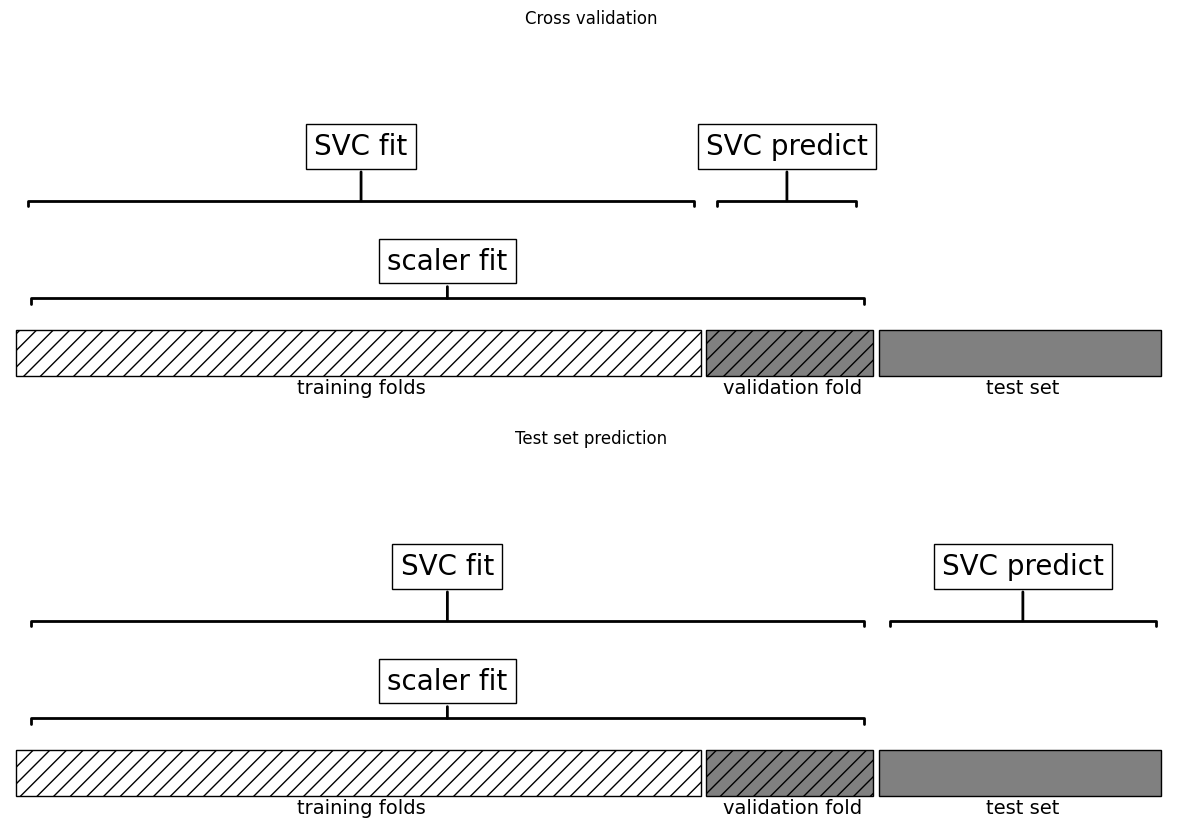

In [6]:
import mglearn

mglearn.plots.plot_improper_processing()

Kebocoran informasi akibat proses penskalaan sebelum pembagian data akan menghasilkan evaluasi yang terlalu optimis dan pemilihan parameter yang tidak akurat, sehingga setiap pemrosesan data harus dilakukan hanya pada bagian data latih di dalam setiap iterasi *cross-validation*. Untuk mengatasi masalah ini, kelas **Pipeline** dalam scikit-learn digunakan guna menyatukan seluruh tahapan pemrosesan dan model ke dalam satu objek tunggal, sehingga memastikan bahwa transformasi data selalu dilakukan dengan benar di dalam loop *cross-validation*.

## Building Pipelines

Penggunaan kelas **Pipeline** memungkinkan kita menyusun alur kerja pelatihan model secara sistematis dengan memberikan daftar langkah berupa *tuple* yang berisi nama identitas dan instansi estimator, seperti menggabungkan `MinMaxScaler` dan `SVM` ke dalam satu kesatuan proses.

In [7]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC())])

Setelah mendefinisikan dua langkah tersebut sebagai "scaler" untuk `MinMaxScaler` dan "svm" untuk `SVC`, kita dapat langsung menjalankan proses pelatihan pada objek *pipeline* tersebut layaknya menggunakan estimator standar lainnya di scikit-learn.

In [8]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('svm', SVC())])

Proses `pipe.fit` bekerja dengan melatih *scaler* pada data latih, mentransformasi data tersebut, lalu melatih model SVM menggunakan hasil skalanya, sementara evaluasi pada data uji dapat dilakukan secara otomatis hanya dengan memanggil fungsi `pipe.score`.

In [9]:
print("Test score: {:.2f}".format(pipe.score(X_test, y_test)))

Test score: 0.97


Memanggil metode `score` pada *pipeline* secara otomatis akan mentransformasi data uji menggunakan *scaler* sebelum mengevaluasinya dengan SVM, yang tidak hanya memberikan hasil identik dengan proses manual tetapi juga menyederhanakan kode serta memungkinkan seluruh rangkaian tersebut digunakan langsung dalam `cross_val_score` atau `GridSearchCV`.

## Using Pipelines in Grid Searches

Penggunaan *pipeline* dalam *grid search* memiliki mekanisme yang sama dengan estimator lainnya, namun terdapat perbedaan sintaksis di mana kita harus menentukan secara spesifik parameter tersebut milik langkah yang mana dengan menggunakan nama langkah diikuti oleh garis bawah ganda serta nama parameternya, seperti "svm__C" atau "svm__gamma".

In [10]:
param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100],
'svm__gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

Dengan paramter ini kita bisa menggunakan GridSearchCV:

In [11]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid.best_score_))
print("Test set score: {:.2f}".format(grid.score(X_test, y_test)))
print("Best parameters: {}".format(grid.best_params_))

Best cross-validation accuracy: 0.98
Test set score: 0.97
Best parameters: {'svm__C': 1, 'svm__gamma': 1}


Berbeda dengan pencarian parameter sebelumnya, sekarang pada setiap pembagian *cross-validation*, `MinMaxScaler` dilatih ulang hanya menggunakan data latih sehingga tidak ada informasi yang bocor dari data uji ke dalam proses pencarian parameter.

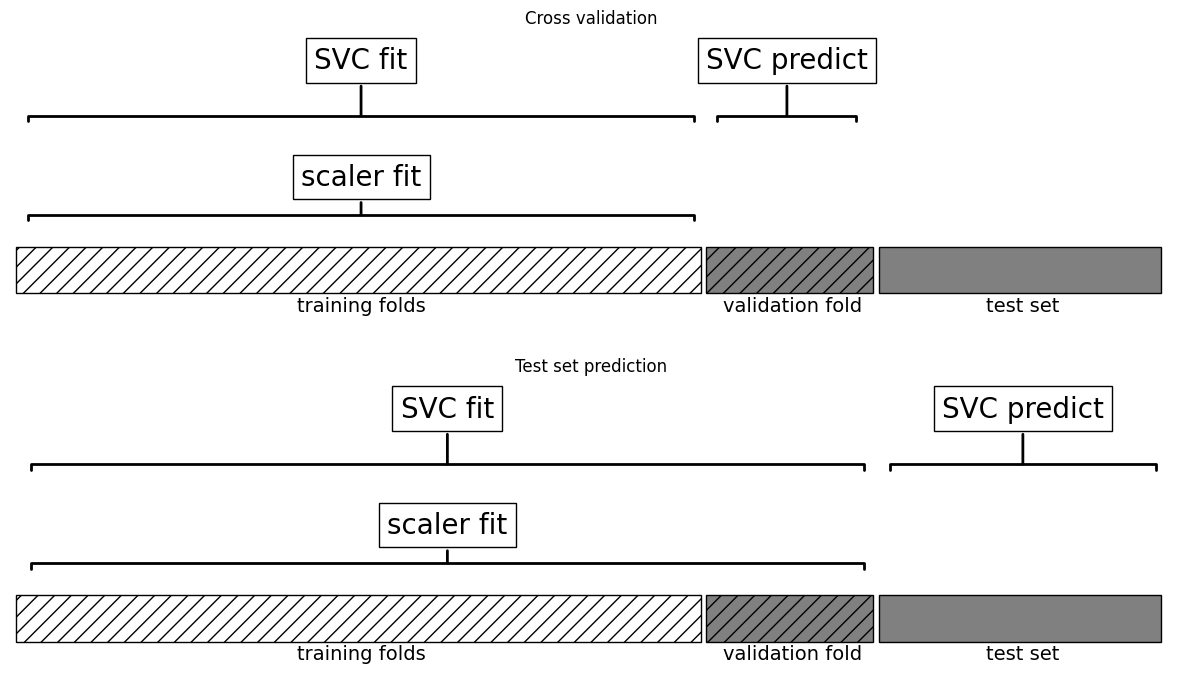

In [12]:
mglearn.plots.plot_proper_processing()

Dampak kebocoran informasi dalam *cross-validation* bervariasi tergantung jenis pemrosesannya, di mana penskalaan data biasanya tidak berdampak fatal, namun penggunaan data uji dalam ekstraksi dan seleksi fitur dapat menyebabkan perbedaan hasil yang signifikan.

## Illustrating Information Leakage

Contoh nyata kebocoran informasi dalam buku *The Elements of Statistical Learning* menunjukkan bahwa pada tugas regresi buatan dengan data yang sepenuhnya acak, model dapat terlihat berperforma sangat baik jika proses seleksi fitur dilakukan sebelum pembagian data. Hal ini terjadi karena informasi dari seluruh dataset digunakan untuk menentukan fitur paling informatif, padahal seharusnya tidak ada hubungan antara fitur dan target.

In [14]:
import numpy as np

rnd = np.random.RandomState(seed=0)
X = rnd.normal(size=(100, 10000))
y = rnd.normal(size=(100,))

Karena data dan target dibuat secara independen tanpa hubungan apa pun, seharusnya tidak ada hal yang bisa dipelajari dari dataset tersebut, namun kita akan mencoba melakukan seleksi fitur paling informatif menggunakan SelectPercentile sebelum mengevaluasi model Ridge melalui cross-validation.

In [15]:
from sklearn.feature_selection import SelectPercentile, f_regression

select = SelectPercentile(score_func=f_regression, percentile=5).fit(X, y)
X_selected = select.transform(X)
print("X_selected.shape: {}".format(X_selected.shape))

X_selected.shape: (100, 500)


In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

print("Cross-validation accuracy (cv only on ridge): {:.2f}".format(
np.mean(cross_val_score(Ridge(), X_selected, y, cv=5))))

Cross-validation accuracy (cv only on ridge): 0.91


Skor $R^2$ sebesar 0,91 yang dihasilkan sangat tidak realistis karena seleksi fitur yang dilakukan di luar *cross-validation* telah membocorkan informasi dari data uji, sehingga fitur yang terpilih secara kebetulan berkorelasi dengan target pada seluruh dataset. Hal ini menyebabkan model tampak bekerja sangat baik pada data acak, sehingga diperlukan penggunaan *pipeline* untuk melakukan *cross-validation* yang benar.

In [17]:
pipe = Pipeline([("select", SelectPercentile(score_func=f_regression, percentile=5)), ("ridge", Ridge())])
print("Cross-validation accuracy (pipeline): {:.2f}".format(np.mean(cross_val_score(pipe, X, y, cv=5))))

Cross-validation accuracy (pipeline): -0.25


Skor $R^2$ yang negatif menunjukkan bahwa model sebenarnya sangat buruk karena penggunaan **Pipeline** memastikan seleksi fitur dilakukan di dalam loop *cross-validation* hanya menggunakan data latih. Dengan memperbaiki masalah kebocoran data ini, terlihat bahwa fitur yang berkorelasi secara kebetulan pada data latih tidak lagi berkorelasi pada data uji, sehingga memberikan kesimpulan yang akurat bahwa model tersebut tidak bekerja sama sekali pada data acak.

## The General Pipeline Interface

Kelas **Pipeline** tidak terbatas pada prapemrosesan dan klasifikasi saja, melainkan dapat menggabungkan berbagai jenis estimator seperti ekstraksi fitur, seleksi fitur, hingga regresi atau pengelompokan. Satu-satunya syarat adalah setiap langkah kecuali langkah terakhir harus memiliki metode `transform` untuk menghasilkan representasi data baru bagi tahap berikutnya. Secara internal, saat menjalankan `fit`, *pipeline* akan memanggil `fit` lalu `transform` pada setiap langkah secara berurutan, sementara pada langkah terakhir hanya metode `fit` yang dipanggil.

In [18]:
def fit(self, X, y):
  X_transformed = X
  for name, estimator in self.steps[:-1]:
    # iterate over all but the final step
    # fit and transform the data
    X_transformed = estimator.fit_transform(X_transformed, y)
  # fit the last step
  self.steps[-1][1].fit(X_transformed, y)
  return self

Saat melakukan prediksi menggunakan **Pipeline**, data akan ditransformasi secara berurutan melewati semua langkah awal, kemudian hasil akhirnya baru diproses dengan memanggil fungsi `predict` pada langkah terakhir.

In [19]:
def predict(self, X):
  X_transformed = X
  for step in self.steps[:-1]:
    # iterate over all but the final step
    # transform the data
    X_transformed = step[1].transform(X_transformed)
  # fit the last step
  return self.steps[-1][1].predict(X_transformed)

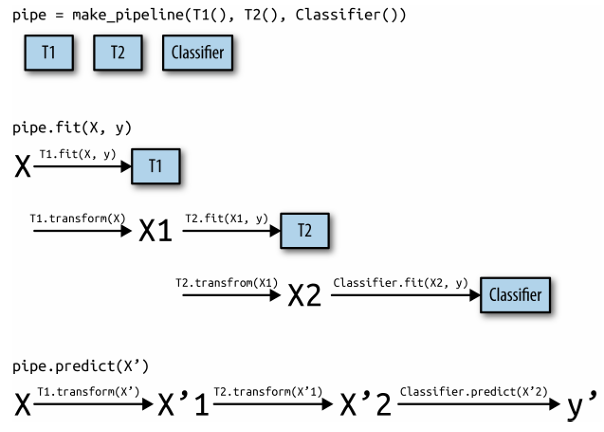

Proses ini bahkan lebih fleksibel karena langkah terakhir dalam **Pipeline** tidak wajib memiliki fungsi `predict`, sehingga kita bisa membuat rangkaian yang hanya berisi transformasi seperti *scaler* dan PCA untuk menghasilkan representasi data baru melalui metode `transform`. Aturan utamanya adalah langkah terakhir hanya diwajibkan memiliki metode `fit`, yang memungkinkan *pipeline* tetap berfungsi meskipun hanya digunakan untuk pemrosesan data tanpa tahap klasifikasi atau regresi.

### Convenient Pipeline Creation with make_pipeline

Fungsi make_pipeline hadir sebagai kemudahan untuk membuat pipeline tanpa perlu memberikan nama manual pada setiap langkah, karena sistem akan secara otomatis menamai setiap tahapan berdasarkan nama kelasnya.

In [20]:
from sklearn.pipeline import make_pipeline
# standard syntax
pipe_long = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC(C=100))])
# abbreviated syntax
pipe_short = make_pipeline(MinMaxScaler(), SVC(C=100))

Objek *pipeline* `pipe_long` dan `pipe_short` menjalankan fungsi yang identik, namun `pipe_short` memiliki langkah-langkah yang dinamai secara otomatis yang dapat diperiksa melalui atribut `steps`.

In [21]:
print("Pipeline steps:\n{}".format(pipe_short.steps))

Pipeline steps:
[('minmaxscaler', MinMaxScaler()), ('svc', SVC(C=100))]


Nama-nama langkah dalam *pipeline* tersebut secara umum adalah versi huruf kecil dari nama kelasnya, seperti `minmaxscaler` dan `svc`, dan jika terdapat beberapa langkah dengan kelas yang sama, maka sebuah angka akan ditambahkan di akhir nama tersebut.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), StandardScaler())
print("Pipeline steps:\n{}".format(pipe.steps))

Pipeline steps:
[('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]


Jika terdapat dua langkah `StandardScaler`, maka langkah pertama akan dinamai `standardscaler-1` dan yang kedua `standardscaler-2`. Namun, dalam situasi seperti ini, lebih disarankan untuk menggunakan konstruksi **Pipeline** dengan nama eksplisit agar setiap tahapan memiliki nama yang lebih bermakna secara semantik.

### Accessing Step Attributes

Kalau mau cek detail di dalem *pipeline*, kayak koefisien model atau komponen PCA, cara paling gampang tinggal pakai atribut `named_steps`. Fitur ini bentuknya mirip kamus (*dictionary*) yang isinya daftar nama langkah yang kita buat tadi buat akses ke setiap estimatornya.

In [23]:
# fit the pipeline defined before to the cancer dataset
pipe.fit(cancer.data)
# extract the first two principal components from the "pca" step
components = pipe.named_steps["pca"].components_
print("components.shape: {}".format(components.shape))

components.shape: (2, 30)


### Accessing Attributes in a Grid-Searched Pipeline

Salah satu alasan utama penggunaan *pipeline* adalah untuk keperluan *grid search*, di mana sering kali kita perlu mengakses langkah-langkah tertentu di dalamnya. Sebagai contoh, kita dapat melakukan *grid search* pada klasifikasi *Logistic Regression* dengan terlebih dahulu menyusun alur kerja menggunakan fungsi `make_pipeline` yang menggabungkan `StandardScaler` untuk penskalaan data sebelum dilanjutkan ke tahap model.

In [24]:
from sklearn.linear_model import LogisticRegression

pipe = make_pipeline(StandardScaler(), LogisticRegression())

Langkah berikutnya adalah membuat kisi parameter dengan menentukan parameter regulasi $C$ untuk *Logistic Regression*. Mengingat alur kerja ini dibuat menggunakan fungsi `make_pipeline`, maka nama langkah tersebut secara otomatis menjadi `logisticregression`. Oleh karena itu, untuk mencari nilai optimal $C$ dalam rentang logaritmik antara 0,01 hingga 100, kita harus mendefinisikan kunci pada kisi parameter dengan format `logisticregression__C`.

In [25]:
param_grid = {'logisticregression__C': [0.01, 0.1, 1, 10, 100]}

Seperti biasa, kita membagi dataset kanker menjadi set pelatihan dan pengujian, kemudian melakukan proses *grid search* untuk melatih model tersebut.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, random_state=4)
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100]})

So how do we access the coefficients of the best LogisticRegression model that was
found by GridSearchCV? From Chapter 5 we know that the best model found by
GridSearchCV, trained on all the training data, is stored in grid.best_estimator_

In [27]:
print("Best estimator:\n{}".format(grid.best_estimator_))

Best estimator:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=1))])


Atribut `best_estimator_` dalam kasus ini merupakan sebuah *pipeline* yang terdiri dari dua tahapan, yaitu `standardscaler` dan `logisticregression`. Guna mengakses tahapan `logisticregression` secara spesifik, kita dapat memanfaatkan atribut `named_steps` pada *pipeline* tersebut sebagaimana telah dijelaskan sebelumnya.

In [28]:
print("Logistic regression step:\n{}".format(
grid.best_estimator_.named_steps["logisticregression"]))

Logistic regression step:
LogisticRegression(C=1)


Setelah memperoleh instansi *Logistic Regression* yang telah dilatih, kita dapat mengakses koefisien atau bobot yang terkait dengan setiap fitur input melalui atribut model tersebut.

In [29]:
print("Logistic regression coefficients:\n{}".format(
grid.best_estimator_.named_steps["logisticregression"].coef_))

Logistic regression coefficients:
[[-0.4475566  -0.34609376 -0.41703843 -0.52889408 -0.15784407  0.60271339
  -0.71771325 -0.78367478  0.04847448  0.27478533 -1.29504052  0.05314385
  -0.69103766 -0.91925087 -0.14791795  0.46138699 -0.1264859  -0.10289486
   0.42812714  0.71492797 -1.08532414 -1.09273614 -0.85133685 -1.04104568
  -0.72839683  0.07656216 -0.83641023 -0.64928603 -0.6491432  -0.42968125]]


Meskipun sintaksis untuk mengakses elemen tersebut terlihat cukup panjang, penggunaan ekspresi ini sangat berguna untuk membantu kita dalam memahami cara kerja serta detail dari model yang telah dibuat.

## Grid-Searching Preprocessing Steps and Model Parameters

Penggunaan *pipeline* memungkinkan kita untuk merangkum seluruh tahapan pemrosesan dalam satu estimator *scikit-learn*. Keuntungan lainnya adalah kita dapat menyesuaikan parameter prapemrosesan berdasarkan hasil dari tugas *supervised learning* seperti regresi atau klasifikasi. Sebagai contoh, alur kerja pada dataset Boston yang sebelumnya menggunakan fitur polinomial sebelum model *Ridge* kini dapat dimodelkan ke dalam sebuah *pipeline* yang terdiri dari tiga tahap: penskalaan data, penghitungan fitur polinomial, dan regresi *Ridge*.

In [31]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge

data = fetch_california_housing()

X_train, X_test, y_train, y_test = train_test_split(
  data.data, data.target, random_state=0
)

pipe = make_pipeline(
  StandardScaler(),
  PolynomialFeatures(),
  Ridge()
)

Untuk menentukan derajat polinomial yang paling tepat atau memutuskan perlu tidaknya penggunaan fitur interaksi, idealnya kita memilih parameter tersebut berdasarkan hasil akhir dari klasifikasi. Dengan menggunakan *pipeline*, kita dapat melakukan pencarian parameter `degree` secara bersamaan dengan parameter `alpha` pada model *Ridge* melalui definisi `param_grid` yang menyertakan awalan nama langkah yang sesuai untuk keduanya.

In [32]:
param_grid = {'polynomialfeatures__degree': [1, 2, 3],
'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

In [33]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [1, 2, 3],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

Kita bisa lihat hasil grid search

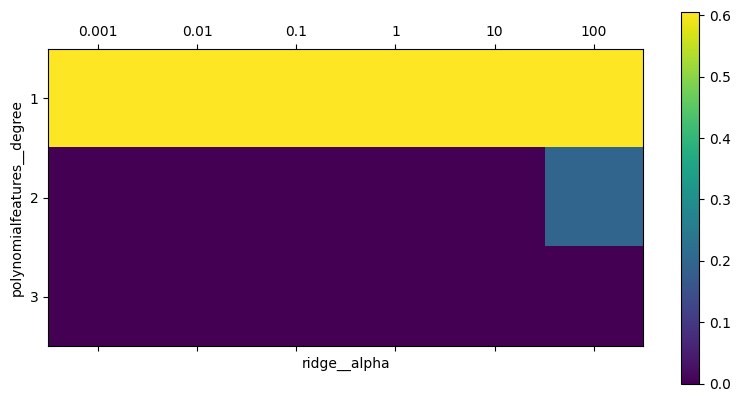

In [35]:
import matplotlib.pyplot as plt

plt.matshow(grid.cv_results_['mean_test_score'].reshape(3, -1),
vmin=0, cmap="viridis")
plt.xlabel("ridge__alpha")
plt.ylabel("polynomialfeatures__degree")
plt.xticks(range(len(param_grid['ridge__alpha'])), param_grid['ridge__alpha'])
plt.yticks(range(len(param_grid['polynomialfeatures__degree'])),
param_grid['polynomialfeatures__degree'])
plt.colorbar()

Berdasarkan hasil validasi silang (*cross-validation*), dapat diamati bahwa penggunaan polinomial derajat dua memberikan peningkatan performa. Namun, penggunaan polinomial derajat tiga menunjukkan hasil yang jauh lebih buruk dibandingkan dengan derajat satu maupun dua. Temuan ini tercermin secara langsung pada kombinasi parameter terbaik yang dihasilkan dari proses pencarian tersebut.

In [36]:
print("Best parameters: {}".format(grid.best_params_))

Best parameters: {'polynomialfeatures__degree': 1, 'ridge__alpha': 10}


In [37]:
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Test-set score: 0.59


Perbandingan tanpa fitur polynoial

In [38]:
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Test-set score: 0.59


Sesuai dengan hasil visualisasi *grid search* pada Gambar 6-4, terlihat bahwa mengabaikan fitur polinomial memberikan hasil yang jauh lebih rendah.

Mencari parameter prapemrosesan secara bersamaan dengan parameter model merupakan strategi yang sangat efektif. Namun, perlu diingat bahwa `GridSearchCV` akan mencoba seluruh kombinasi parameter yang ditentukan. Oleh karena itu, penambahan parameter ke dalam kisi akan meningkatkan jumlah model yang harus dibangun secara eksponensial.

## Grid-Searching Which Model To Use

Integrasi antara `GridSearchCV` dan **Pipeline** dapat dikembangkan lebih jauh dengan melakukan pencarian terhadap langkah-langkah aktual yang dijalankan dalam alur kerja, seperti memilih antara penggunaan `StandardScaler` atau `MinMaxScaler`. Strategi ini memperluas ruang pencarian secara signifikan sehingga harus dipertimbangkan dengan cermat, karena mencoba seluruh kombinasi solusi biasanya bukan merupakan strategi pembelajaran mesin yang efisien.

Sebagai contoh, kita dapat membandingkan model `RandomForestClassifier` dan `SVC` pada dataset Iris. Mengingat `SVC` memerlukan penskalaan data, kita dapat menyertakan opsi pencarian antara menggunakan `StandardScaler` atau tanpa prapemrosesan sama sekali. Sebaliknya, untuk `RandomForestClassifier`, prapemrosesan tidak diperlukan. Proses ini dimulai dengan mendefinisikan *pipeline* menggunakan nama langkah yang eksplisit, yang terdiri dari tahap prapemrosesan dan tahap klasifikasi, dengan instansiasi awal menggunakan `SVC` dan `StandardScaler`.

In [39]:
pipe = Pipeline([('preprocessing', StandardScaler()), ('classifier', SVC())])

Selanjutnya, kita dapat mendefinisikan `parameter_grid` untuk proses pencarian. Dalam hal ini, kita ingin membandingkan penggunaan `RandomForestClassifier` dan `SVC`. Karena kedua algoritma tersebut memiliki parameter yang berbeda untuk dioptimalkan serta kebutuhan prapemrosesan yang berbeda pula, kita dapat memanfaatkan daftar kisi pencarian (*list of search grids*).

Untuk menetapkan sebuah estimator pada tahapan tertentu dalam *pipeline*, kita menggunakan nama tahapan tersebut sebagai nama parameter. Apabila kita ingin melewati suatu tahapan—misalnya karena `RandomForest` tidak memerlukan prapemrosesan—kita dapat mengatur nilai tahapan tersebut menjadi `None`.

In [41]:
from sklearn.ensemble import RandomForestClassifier
param_grid = [
{'classifier': [SVC()], 'preprocessing': [StandardScaler(), None],
'classifier__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]},
{'classifier': [RandomForestClassifier(n_estimators=100)],
'preprocessing': [None], 'classifier__max_features': [1, 2, 3]}]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, random_state=0)
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best params:\n{}\n".format(grid.best_params_))
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Best params:
{'classifier': SVC(), 'classifier__C': 10, 'classifier__gamma': 0.01, 'preprocessing': StandardScaler()}

Best cross-validation score: 0.99
Test-set score: 0.98


Hasil dari grid search tersebut menunjukkan bahwa penggunaan SVC dengan prapemrosesan StandardScaler, serta parameter $C=10$ dan $\gamma=0.01$, memberikan hasil performa yang paling optimal.

## Summary and Outlook

Pada bab ini, kita telah mempelajari kelas Pipeline sebagai instrumen serbaguna untuk merangkaikan berbagai tahapan pemrosesan dalam alur kerja pembelajaran mesin. Mengingat aplikasi praktis di dunia nyata jarang hanya melibatkan satu model terisolasi, penggunaan pipeline memungkinkan kita merangkum seluruh rangkaian proses ke dalam satu objek Python yang tetap mematuhi antarmuka standar scikit-learn seperti fit, predict, dan transform.

Penerapan Pipeline menjadi sangat krusial, terutama saat melakukan evaluasi model dengan cross-validation dan optimasi parameter melalui grid search, guna memastikan validitas proses evaluasi. Selain menghasilkan kode yang lebih ringkas, kelas ini juga meminimalkan risiko kesalahan teknis, seperti kekeliruan urutan transformasi atau terlewatnya pemrosesan pada set pengujian. Meskipun penentuan kombinasi ekstraksi fitur dan model sering kali membutuhkan eksperimen, pipeline mempermudah proses uji coba tersebut secara sistematis. Dengan penguasaan alat dan algoritma ini, kita kini memiliki kompetensi dasar yang diperlukan untuk mengimplementasikan pembelajaran mesin secara praktis.